# Results Comparison

This notebook will evaluate and compare the performance of all of the models using Tensorboard and code-based metrics.


## Import Dependencies


In [1]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle

In [2]:
%matplotlib inline

## run tensorboard logging


In [3]:
# %load_ext tensorboard
# %tensorboard --logdir TensorBoard/runs --port 6006

## Read Events Files


### paths and defns


In [4]:
RUNS_DIR: Path = Path('TensorBoard/runs')


model_groups: dict[str, dict[str, list[pd.DataFrame]]] = {
    'YOLO': {
        'yolov8-amy': [],
        'yolov8-Joachim': [],
        'yolov11': [],
        'yolov12': []
    },
    'COCO': {
        'efficientDet': [],
        'faster-rcnn': [],
        'rf-detr': [],
        'retina-net': []
    },
    'SIGN_ATTR': {
        'sign-condition': [],
        'sign-shape': [],
        'viewing-angle': [],
        'mounting-type': []
    }
}

# to be used later
model_results: dict[str, dict[str, pd.DataFrame]] = {
    'YOLO': {
        'yolov8-amy': pd.DataFrame(),
        'yolov8-Joachim': pd.DataFrame(),
        'yolov11': pd.DataFrame(),
        'yolov12': pd.DataFrame()
    },
    'COCO': {
        'efficientDet': pd.DataFrame(),
        'faster-rcnn': pd.DataFrame(),
        'rf-detr': pd.DataFrame(),
        'retina-net': pd.DataFrame()
    },
    'SIGN_ATTR': {
        'sign-condition': pd.DataFrame(),
        'sign-shape': pd.DataFrame(),
        'viewing-angle': pd.DataFrame(),
        'mounting-type': pd.DataFrame()
    }
}

In [5]:
# fn to load a single file
def extract_scalars_from_event(event_path, model_name, category) -> pd.DataFrame:
    """
    Read a single event file and returns a DataFrame of all scalar metrics.
    """
    # Load the event file with full size guidance
    ea = EventAccumulator(str(event_path), size_guidance={'scalars': 0})
    ea.Reload()

    scalar_tags = ea.Tags()['scalars']
    if not scalar_tags:
        return pd.DataFrame()  # Return empty if no scalars found

    dfs = []

    # Extract data for every metric (tag) found in the file
    for tag in scalar_tags:
        events = ea.Scalars(tag)
        temp_df = pd.DataFrame(events)

        # Keep relevant columns and rename
        temp_df = temp_df[['step', 'value']]
        temp_df['metric'] = tag
        dfs.append(temp_df)

    # Combine all metrics for this model
    if dfs:
        full_df = pd.concat(dfs, ignore_index=True)
        full_df['model'] = model_name
        full_df['category'] = category
        return full_df
    return pd.DataFrame()

In [6]:
# seqrch for logs


for cat, models_list in model_groups.items():
    for model in models_list:

        # get model dir
        model_dir = RUNS_DIR / model

        # find event files
        event_files = list(model_dir.rglob('events.out.tfevents.*'))

        # debug print
        print(event_files)

        for event in event_files:
            # try save the results
            try:
                # save every possible event file, we'll handle dupes and merges later
                df = extract_scalars_from_event(event, model, cat)
                if not df.empty:
                    model_groups[cat][model].append(df)
                else:
                    raise ValueError(
                        f'No scalar data found in event file for model: {model}')
            except Exception as e:
                print(f'Error processing model: {model}. Error: {e}')

[WindowsPath('TensorBoard/runs/yolov8-amy/events.out.tfevents.1768935150.Amy.2004.0'), WindowsPath('TensorBoard/runs/yolov8-amy/events.out.tfevents.1768938251.Amy.24384.0'), WindowsPath('TensorBoard/runs/yolov8-amy/events.out.tfevents.1768938343.Amy.23720.0'), WindowsPath('TensorBoard/runs/yolov8-amy/events.out.tfevents.1768971748.Amy.12236.0')]
Error processing model: yolov8-amy. Error: No scalar data found in event file for model: yolov8-amy
Error processing model: yolov8-amy. Error: No scalar data found in event file for model: yolov8-amy
[WindowsPath('TensorBoard/runs/yolov8-Joachim/events.out.tfevents.1769681434.JoachimAsus')]
[WindowsPath('TensorBoard/runs/yolov11/events.out.tfevents.1769081489.EllynRoseDebrincat.10948.1'), WindowsPath('TensorBoard/runs/yolov11/events.out.tfevents.1769082980.EllynRoseDebrincat.23580.0')]
Error processing model: yolov11. Error: No scalar data found in event file for model: yolov11
[WindowsPath('TensorBoard/runs/yolov12/events.out.tfevents.17685125

In [7]:
for cat, models_list in model_groups.items():
    for model in models_list:
        for result in models_list[model]:
            print(result.head())

   step    value          metric       model category
0     1  1.04562  train/box_loss  yolov8-amy     YOLO
1     2  0.99562  train/box_loss  yolov8-amy     YOLO
2     3  1.02341  train/box_loss  yolov8-amy     YOLO
3     4  0.95569  train/box_loss  yolov8-amy     YOLO
4     5  1.03757  train/box_loss  yolov8-amy     YOLO
   step    value          metric       model category
0    78  0.68009  train/box_loss  yolov8-amy     YOLO
1    79  0.62684  train/box_loss  yolov8-amy     YOLO
2    80  0.65914  train/box_loss  yolov8-amy     YOLO
3    81  0.56997  train/box_loss  yolov8-amy     YOLO
4    82  0.64140  train/box_loss  yolov8-amy     YOLO
   step        value metric           model category
0     1   489.321014   time  yolov8-Joachim     YOLO
1     2   938.745972   time  yolov8-Joachim     YOLO
2     3  1368.349976   time  yolov8-Joachim     YOLO
3     4  1823.130005   time  yolov8-Joachim     YOLO
4     5  2262.780029   time  yolov8-Joachim     YOLO
   step    value          metric  

In [8]:
# useful fns for getting the map50_95 and map50 headers

def is_map50_95(header) -> bool:
    '''AP instead of mAP because of rfdetr, 9 instread of 95 because of bug in rfdetr library, not EMA because we want the raw data'''
    return 'AP' in header and '50' in header and 'EMA' not in header and '9' in header


def is_map50(header) -> bool:
    '''AP instead of mAP because of rfdetr, 9 instead of 95 because of bug in rfdetr library, not EMA because we want the raw data'''
    return 'AP' in header and '50' in header and 'EMA' not in header and '9' not in header

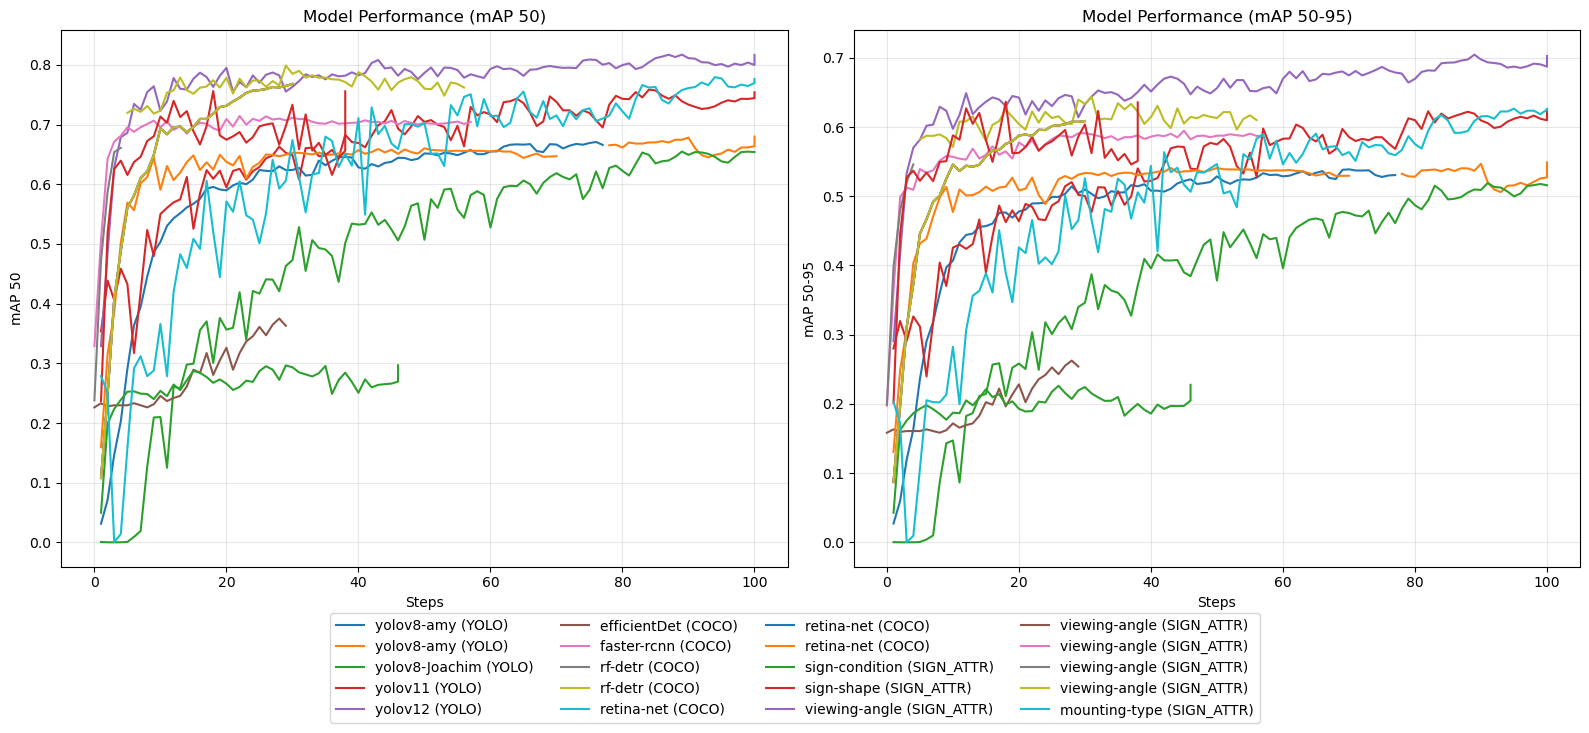

Total DataFrames processed: 24
Missing DataFrames: 0
Total mAP50 headers found: 20
Total mAP50-95 headers found: 20


In [9]:
# Increase figure width to accommodate two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))  # type: ignore

stats_dict = {
    'missing_dfs': 0,
    'total_dfs': 0,
    'mAP50_headers': set(),
    'map50_header_count': 0,
    'mAP50-95_headers': set(),
    'map50-95_header_count': 0
}


def get_label(df):
    '''helper functions for plotting consistency'''
    return f"{df['model'].iloc[0]} ({df['category'].iloc[0]})"


for model in model_groups.values():
    for name, df_list in model.items():
        for df in df_list:
            stats_dict['total_dfs'] += 1
            if df.empty:
                stats_dict['missing_dfs'] += 1
                continue

            headers = df['metric'].unique()
            for header in headers:
                subset = df[df['metric'] == header]
                label = get_label(df)

                # Plot Left: mAP 50
                if is_map50(header):
                    stats_dict['mAP50_headers'].add(header)
                    stats_dict['map50_header_count'] += 1
                    ax1.plot(subset['step'], subset['value'], label=label)

                # Plot Right: mAP 50-95
                elif is_map50_95(header):
                    stats_dict['mAP50-95_headers'].add(header)
                    stats_dict['map50-95_header_count'] += 1
                    ax2.plot(subset['step'], subset['value'], label=label)

# --- Format Left Plot ---
ax1.set_title('Model Performance (mAP 50)')
ax1.set_xlabel('Steps')
ax1.set_ylabel('mAP 50')
ax1.grid(True, alpha=0.3)

# --- Format Right Plot ---
ax2.set_title('Model Performance (mAP 50-95)')
ax2.set_xlabel('Steps')
ax2.set_ylabel('mAP 50-95')
ax2.grid(True, alpha=0.3)

# --- Handle Legend ---
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.05), ncol=4)

# Make room at the bottom for the shared legend
plt.tight_layout(rect=[0, 0.1, 1, 1])  # type: ignore
plt.show()

print(f"Total DataFrames processed: {stats_dict['total_dfs']}")
print(f"Missing DataFrames: {stats_dict['missing_dfs']}")
print(f"Total mAP50 headers found: {stats_dict['map50_header_count']}")
print(f"Total mAP50-95 headers found: {stats_dict['map50-95_header_count']}")

the results are a bit broken, lets try fix them

~~2~~ 3 main issues:

- overlapping results for the same plot -> how do we choose which one to keep
- one plot cut up into pieces -> can we join them
- some dfs dont have what we want -> just remove them


In [10]:
# we can use num dfs > 1 to detect issues
for model in model_groups.values():
    for name, df_list in model.items():
        if len(df_list) > 1:
            print(f'model: {name}, df count: {len(df_list)}')

            # check if condition 1 or 2
            epochs_sets = [set(df['step'].unique()) for df in df_list]

            # condition 2: check if dfs have different epochs (sequential runs)
            all_epochs = set().union(*epochs_sets)
            if len(all_epochs) == sum(len(epochs) for epochs in epochs_sets):
                print(
                    f'  Condition 2 met: Different epochs among DataFrames for model: {name}')
                combined_df = pd.concat(df_list, ignore_index=True)
                model[name] = [combined_df] # this works so we'll leave it
                continue  # Move to next model group

            # condition 1: check if all dfs have overlapping epochs
            common_epochs = set.intersection(*epochs_sets)
            if common_epochs:
                print(
                    f'  Condition 1 met: Overlapping epochs among DataFrames for model: {name}')

                best_df = None
                best_map = -np.inf

                for df in df_list:
                    # Filter for the mAP 50 and 50-95
                    subset = df[df['metric'].apply(
                        lambda x: is_map50_95(x) or is_map50(x))]

                    if not subset.empty:
                        # If a file has multiple metrics, we group by metric to find the max of either
                        # We use the max value at the final step to determine the "healthiest" log file
                        last_step = subset['step'].max()
                        final_values = subset[subset['step']
                                              == last_step]['value'].values

                        if len(final_values) > 0:
                            current_max = np.max(final_values)

                            if current_max > best_map:
                                best_map = current_max
                                best_df = df

                if best_df is not None:
                    print(
                        f'   Best DataFrame for model {name} selected (Max Metric: {best_map:.4f})')
                    model[name] = [best_df]
                else:
                    print(
                        f'   Warning: No mAP50 or mAP50-95 found in any files for {name}')
                    # model[name] = [max(df_list, key=len)]  # we do this in the next step

            # condition 3: df is missing mAP50 and mAP50-95
            # Create a new list to keep dfs which have the metrics we want
            valid_dfs = [
                df for df in df_list
                if any(df['metric'].apply(lambda x: is_map50(x) or is_map50_95(x)))
            ]

            # detect if we removed anything
            if len(valid_dfs) < len(df_list):
                print(
                    f'  Condition 3 met: Removed {len(df_list) - len(valid_dfs)} DataFrames missing metrics for model: {name}')

            # Update the model with the filtered list
            if valid_dfs:
                # update model with valid dfs
                model[name] = valid_dfs
            else:
                print(
                    f'   Warning: All DataFrames removed for {name}, no valid data remains.')
                # Handle the case where the list is empty (optional: delete the model key or keep empty list)
                model[name] = []

model: yolov8-amy, df count: 2
  Condition 2 met: Different epochs among DataFrames for model: yolov8-amy
model: rf-detr, df count: 2
  Condition 2 met: Different epochs among DataFrames for model: rf-detr
model: retina-net, df count: 7
  Condition 3 met: Removed 4 DataFrames missing metrics for model: retina-net
model: viewing-angle, df count: 5
  Condition 1 met: Overlapping epochs among DataFrames for model: viewing-angle
   Best DataFrame for model viewing-angle selected (Max Metric: 0.7681)


In [11]:
# now lets keep only a single df
for cat, model in model_groups.items():
    for name, df_list in model.items():
        if len(df_list) == 0:
            print('list empty')
            continue
            
            
        model_results[cat][name] = max(df_list, key=lambda df: len(df))
        
del model_groups  # dont ever use this again

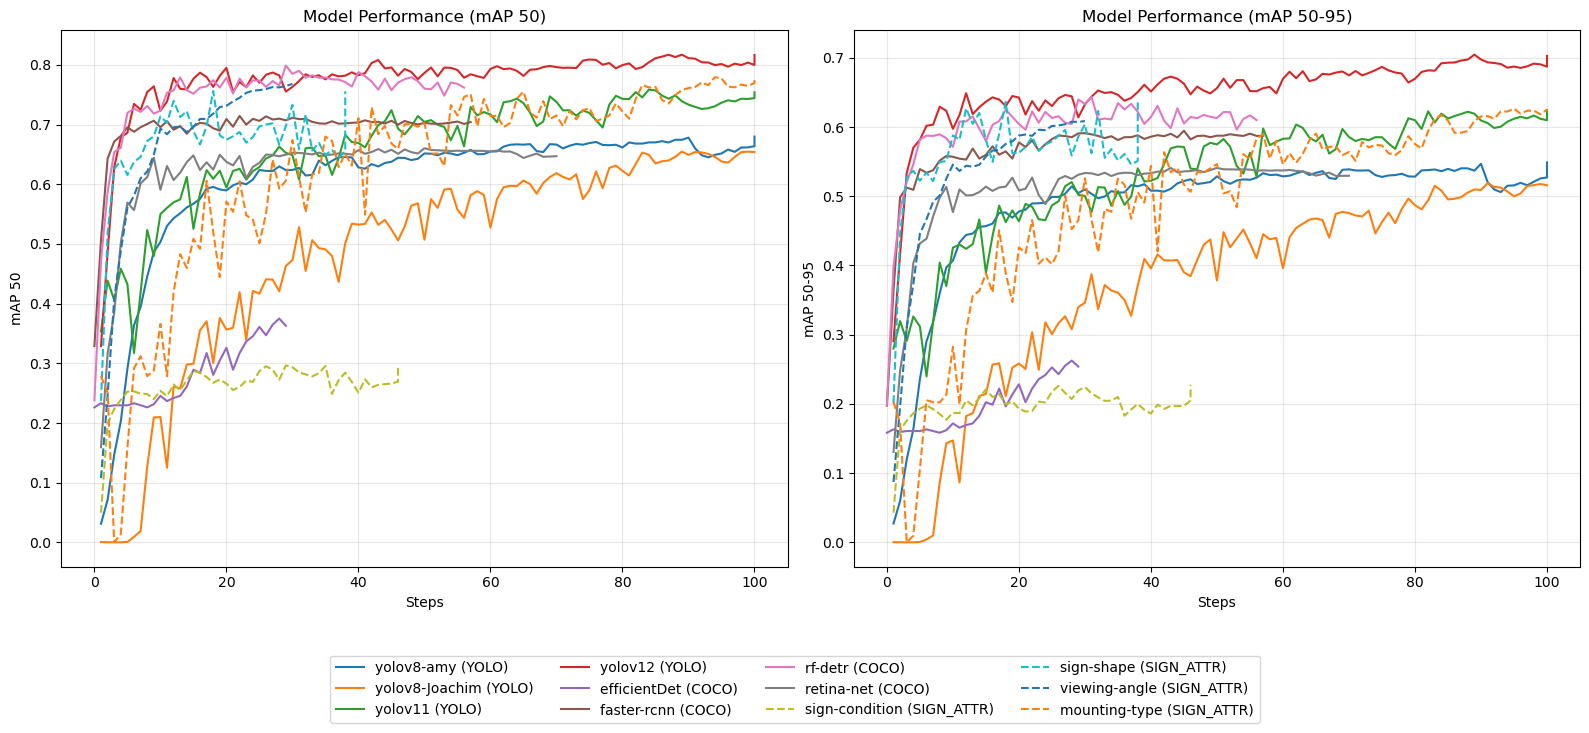

Total DataFrames processed: 12
Missing DataFrames: 0
Total mAP50 headers found: 12
Total mAP50-95 headers found: 12


In [17]:
# re-plot using 'fixed' dfs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))  # type: ignore

# reset stats
stats_dict = {
    'missing_dfs': 0,
    'total_dfs': 0,
    'mAP50_headers': set(),
    'map50_header_count': 0,
    'mAP50-95_headers': set(),
    'map50-95_header_count': 0
}

for model in model_results.values():
    for name, df in model.items():
        stats_dict['total_dfs'] += 1
        if df.empty:  # because not everyone pushed yet
            stats_dict['missing_dfs'] += 1
            continue

        headers = df['metric'].unique()
        for header in headers:
            subset = df[df['metric'] == header]
            label = get_label(df)
            
            ls = '--' if 'SIGN_ATTR' in label else '-'
            
            # Plot Left: mAP 50
            if is_map50(header):
                stats_dict['mAP50_headers'].add(header)
                stats_dict['map50_header_count'] += 1
                ax1.plot(subset['step'], subset['value'], label=label, linestyle=ls)
            
            # Plot Right: mAP 50-95
            elif is_map50_95(header):
                stats_dict['mAP50-95_headers'].add(header)
                stats_dict['map50-95_header_count'] += 1
                ax2.plot(subset['step'], subset['value'], label=label, linestyle=ls)

# --- Format Left Plot ---
ax1.set_title('Model Performance (mAP 50)')
ax1.set_xlabel('Steps')
ax1.set_ylabel('mAP 50')
ax1.grid(True, alpha=0.3)

# --- Format Right Plot ---
ax2.set_title('Model Performance (mAP 50-95)')
ax2.set_xlabel('Steps')
ax2.set_ylabel('mAP 50-95')
ax2.grid(True, alpha=0.3)

# --- Handle Legend ---
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.05), ncol=4)

# Make room at the bottom for the shared legend
plt.tight_layout(rect=[0, 0.1, 1, 1])  # type: ignore
plt.show()

print(f"Total DataFrames processed: {stats_dict['total_dfs']}")
print(f"Missing DataFrames: {stats_dict['missing_dfs']}")
print(f"Total mAP50 headers found: {stats_dict['map50_header_count']}")
print(f"Total mAP50-95 headers found: {stats_dict['map50-95_header_count']}")

### comparing apples with apples


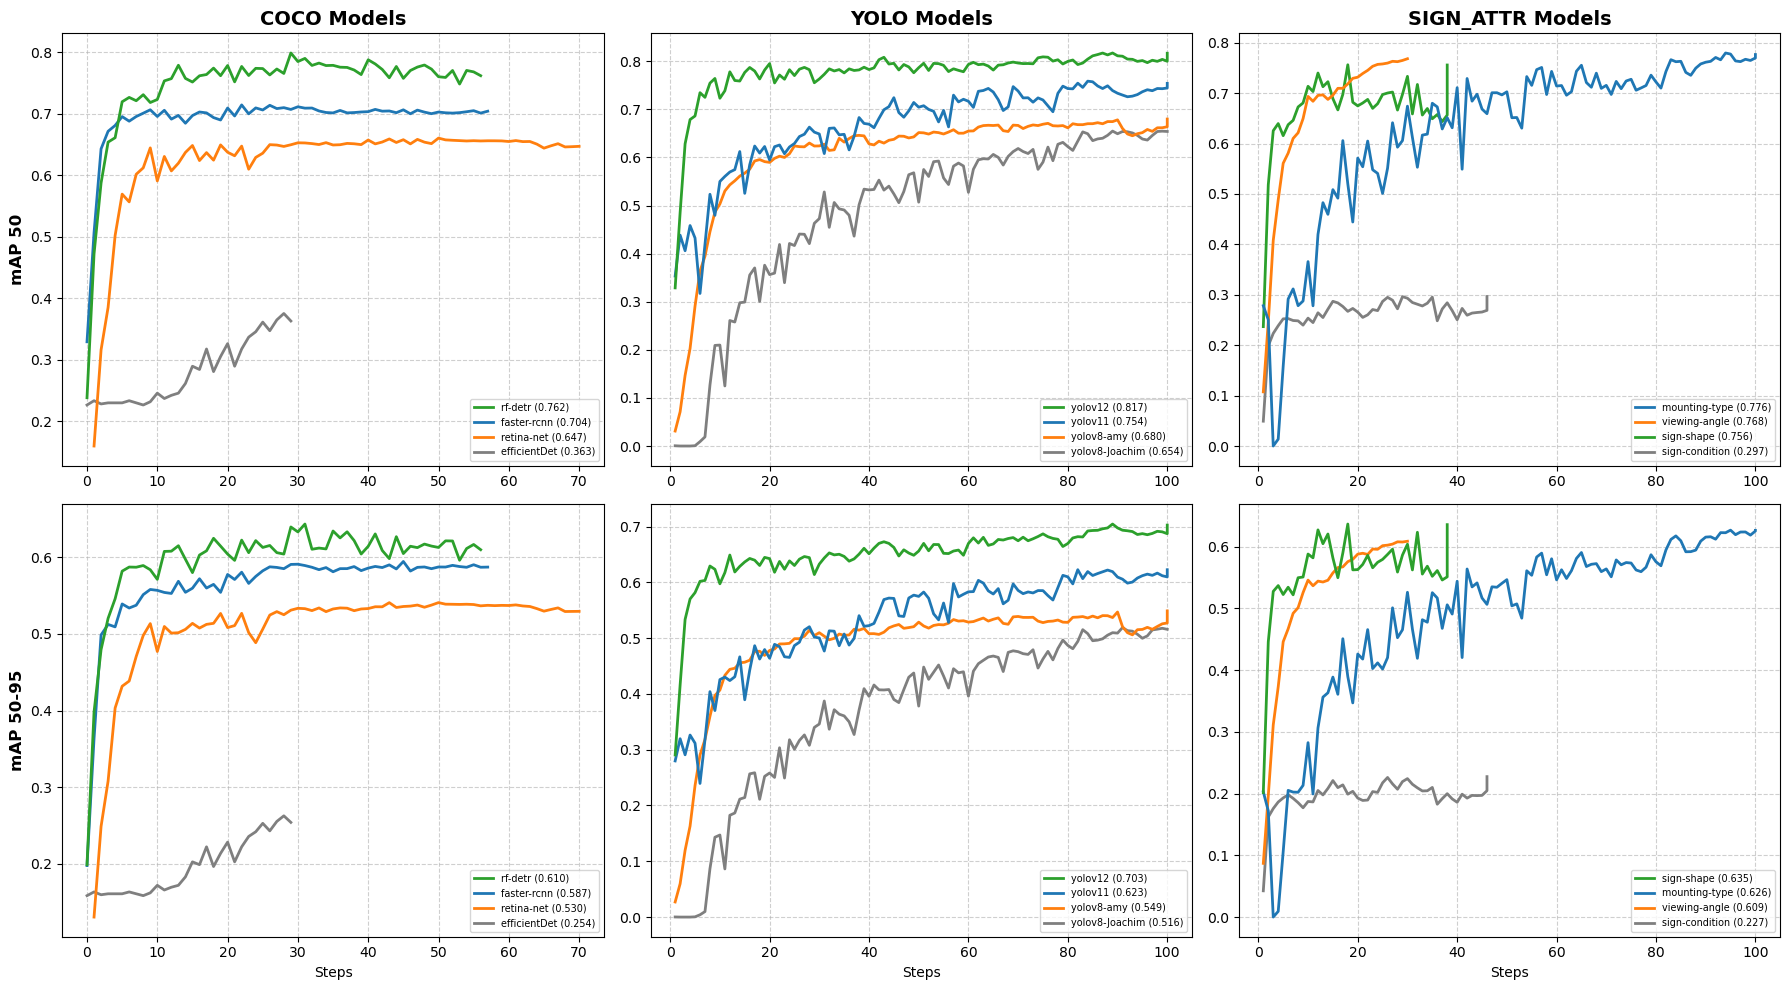

In [13]:
import matplotlib.pyplot as plt

# Color priority: Green, Blue, Orange, Gray, etc.
color_palette = ['#2ca02c', '#1f77b4',
                 '#ff7f0e', '#7f7f7f', '#bcbd22', '#17becf']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

category_map = {'COCO': 0, 'YOLO': 1, 'SIGN_ATTR': 2}
row_configs = [
    (0, is_map50, 'mAP 50'),
    (1, is_map50_95, 'mAP 50-95')
]

for model_name, model_content in model_results.items():
    col_idx = category_map.get(model_name)
    if col_idx is None:
        continue

    # --- STEP 1: GENERATE MASTER COLOR MAP (Based on mAP 50-95) ---
    # We scan the mAP 50-95 data first to determine who gets what color.
    # The "Best" model in 50-95 gets Green, 2nd gets Blue, etc.

    ranking_data = []
    for name, df in model_content.items():
        if df.empty:
            continue

        # Find 50-95 header for ranking
        headers_95 = [h for h in df['metric'].unique() if is_map50_95(h)]
        if headers_95:
            subset = df[df['metric'] == headers_95[0]]
            if not subset.empty:
                last_val = subset['value'].iloc[-1]
                ranking_data.append(
                    {'name': df['model'].iloc[0], 'val': last_val})

    # Sort by value descending (Best first)
    ranking_data.sort(key=lambda x: x['val'], reverse=True)

    # Create the map: {'yolov8': '#2ca02c', 'yolov11': '#1f77b4', ...}
    master_color_map = {}
    for i, item in enumerate(ranking_data):
        c = color_palette[i] if i < len(color_palette) else '#7f7f7f'
        master_color_map[item['name']] = c

    # Fallback: If a model only has map50 but no map50-95, give it gray
    # (This prevents crashes if data is missing)

    # --- STEP 2: PLOT BOTH ROWS USING MASTER MAP ---
    for row_idx, metric_func, ylabel in row_configs:
        ax = axes[row_idx, col_idx] # type: ignore

        # We still collect data to sort the LEGEND properly for this specific plot,
        # but we do NOT change the line colors.
        plot_items = []

        for name, df in model_content.items():
            if df.empty:
                continue

            headers = [h for h in df['metric'].unique() if metric_func(h)]
            if not headers:
                continue

            subset = df[df['metric'] == headers[0]]
            model_label = df['model'].iloc[0]

            if not subset.empty:
                last_val = subset['value'].iloc[-1]

                # Retrieve color from master map, default to gray if not found
                fixed_color = master_color_map.get(model_label, '#7f7f7f')

                plot_items.append({
                    'label': model_label,
                    'subset': subset,
                    'last_val': last_val,
                    'color': fixed_color
                })

        # Sort strictly for visual layering (z-order) and legend order
        plot_items.sort(key=lambda x: x['last_val'], reverse=True)

        for i, item in enumerate(plot_items):
            ax.plot(
                item['subset']['step'],
                item['subset']['value'],
                label=f"{item['label']} ({item['last_val']:.3f})",
                color=item['color'],  # <--- USES FIXED COLOR
                linewidth=2,
                zorder=10 - i
            )

        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize='x-small', loc='lower right')

        if col_idx == 0:
            ax.set_ylabel(ylabel, fontweight='bold', fontsize=12)

# Titles and formatting
column_titles = ['COCO Models', 'YOLO Models', 'SIGN_ATTR Models']
for i, title in enumerate(column_titles):
    axes[0, i].set_title(title, fontweight='bold', fontsize=14) # type: ignore

for ax in axes[1, :]: # type: ignore
    ax.set_xlabel('Steps')

plt.tight_layout()
plt.show()

In [14]:
# save the compiled data
with open('compiled_model_data.pkl', 'wb') as f:
    pickle.dump(model_results, f)